## Banking FAQ--- NLP Chatbot Notebook

### TF_ IDF . Cosine Similarity . Intent Classification

- This notebook walks through building an FAQ-retrieval chatbot on the Banking FAQ Dataset v2.0

In [1]:
# Standard Library
import warnings
warnings.filterwarnings("ignore")

# Data
import pandas as pd
import numpy as np

# NLP

import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt    
import matplotlib.cm as cm
import seaborn as sns    

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = ['#2563eb','#16a34a','#dc2626','#d97706','#7c3aed']

print('✅  All imports successful')


✅  All imports successful


## 1. Load & Explore the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\aka90\Desktop\sql\data file\banking_knowledge_base.csv")

In [3]:
df.head()

,Section,Question,Answer
0,Basic Accounts,What is a Savings Account?,An account designed for individuals to park th...
1,Basic Accounts,What is a Current Account?,An account meant for businesses with no limit ...
2,Basic Accounts,What is a Fixed Deposit (FD)?,An investment where you lock a sum of money fo...
3,Basic Accounts,What does KYC stand for?,Know Your Customer. It's a process to verify t...
4,Basic Accounts,What is a Check/Cheque?,A written document that orders a bank to pay a...


In [4]:
df.columns = df.columns.str.strip()

In [5]:
df = df.rename(columns={'Section': 'Category'})

In [6]:
df.columns

Index(['Category', 'Question', 'Answer'], dtype='object')

In [7]:
df.shape

(100, 3)

In [8]:
# Missing Value Cheack 

df.isna().sum()

Category    0
Question    0
Answer      0
dtype: int64

In [9]:
df['Category'].value_counts()

Category
Basic Accounts           20
Digital Banking          20
Loans & Interest         20
Operations & Security    20
General Finance          20
Name: count, dtype: int64

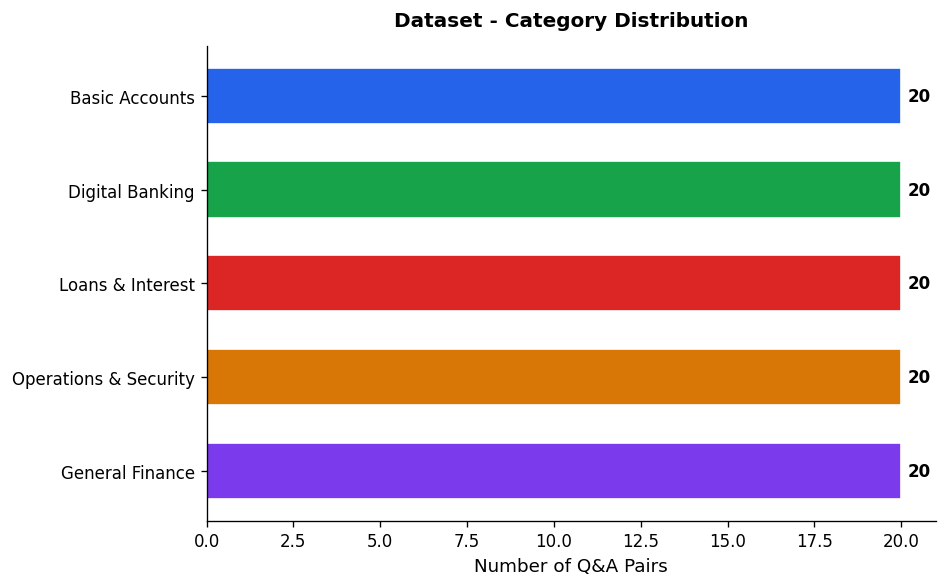

In [11]:
# Category Distribution bar chart

counts = df['Category'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(counts.index, counts.values, color=PALETTE, edgecolor="white", height=0.6)
ax.bar_label(bars, padding=4, fontsize=10, fontweight="bold")
ax.set_xlabel('Number of Q&A Pairs', fontsize=11)
ax.set_title("Dataset - Category Distribution", fontsize=12, fontweight="bold", pad =12)
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

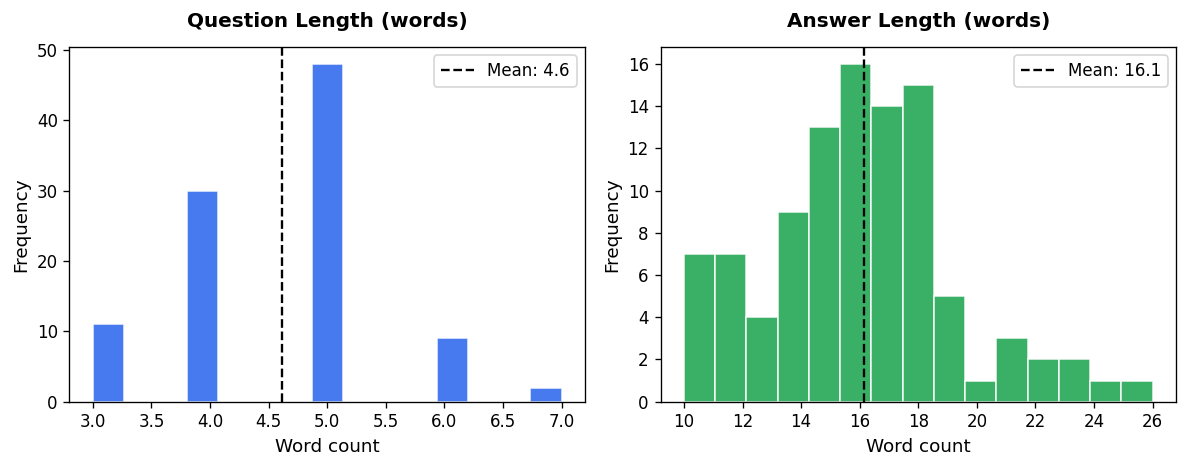

,q_len,a_len
count,100.0,100.0
mean,4.6,16.1
std,0.9,3.1
min,3.0,10.0
25%,4.0,14.0
50%,5.0,16.0
75%,5.0,18.0
max,7.0,26.0


In [12]:
# Question & Answer length statistics

df['q_len'] = df['Question'].str.split().str.len()
df['a_len'] = df['Answer'].str.split().str.len()

fig, axes = plt.subplots(1,2, figsize=(10, 4))
for ax, col, title, colour in zip(
    axes,
    ['q_len', 'a_len'],
    ['Question Length (words)', 'Answer Length (words)'],
    [PALETTE[0], PALETTE[1]]
):
    ax.hist(df[col], bins=15, color=colour, edgecolor ='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.4,
               label=f'Mean: {df[col].mean():.1f}')
    
    ax.set_xlabel('Word count', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

df[['q_len', 'a_len']].describe().round(1)

## 2. Text Pre-Processing

In [13]:
def preprocess(text: str) -> str:
    """Lowercase → strip punctuation → collapse whitespace."""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)   # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # collapse spaces
    return text

df['clean_question'] = df['Question'].apply(preprocess)

# Spot-check
for orig, clean in zip(df['Question'][:3], df['clean_question'][:3]):
    print(f'  Original : {orig}')
    print(f'  Cleaned  : {clean}')
    print()

  Original : What is a Savings Account?
  Cleaned  : what is a savings account

  Original : What is a Current Account?
  Cleaned  : what is a current account

  Original : What is a Fixed Deposit (FD)?
  Cleaned  : what is a fixed deposit fd



## 3. TF-IDF Vectorisation

In [14]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),    # unigrams + bigrams
    max_features=2000,
    sublinear_tf=True,     # log-normalise TF
    stop_words='english'
)

tfidf_matrix = vectorizer.fit_transform(df['clean_question'])
feature_names = vectorizer.get_feature_names_out()

print(f'Vocabulary size : {len(feature_names):,}')
print(f'TF-IDF matrix   : {tfidf_matrix.shape}  (docs × features)')

Vocabulary size : 216
TF-IDF matrix   : (100, 216)  (docs × features)


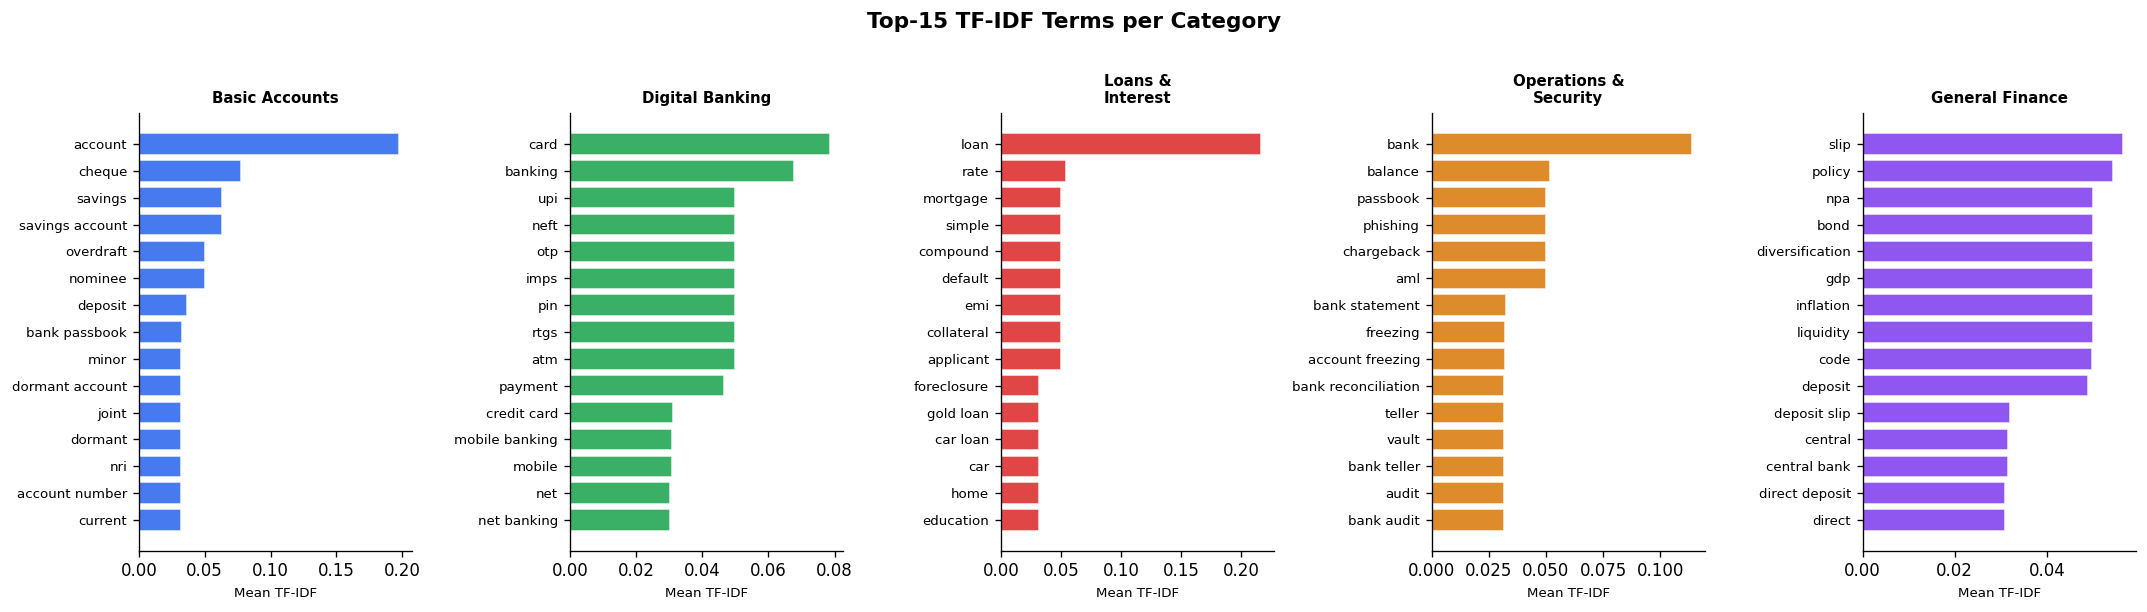

In [15]:
# ── Top-15 TF-IDF tokens per category ───────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, (cat, colour) in zip(axes, zip(df['Category'].unique(), PALETTE)):
    mask = (df['Category'] == cat).to_numpy()  # ← fix: convert to NumPy array
    cat_matrix = tfidf_matrix[mask]
    mean_scores = np.asarray(cat_matrix.mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[-15:][::-1]
    top_terms = [feature_names[i] for i in top_idx]
    top_scores = mean_scores[top_idx]
    ax.barh(top_terms[::-1], top_scores[::-1], color=colour, edgecolor='white', alpha=0.85)
    ax.set_title(cat.replace(' & ', ' &\n'), fontsize=9, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top','right']].set_visible(False)
    ax.set_xlabel('Mean TF-IDF', fontsize=8)
plt.suptitle('Top-15 TF-IDF Terms per Category', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4 · FAQ Retrieval via Cosine Similarity
Cosine similarity measures the angle between two vectors — a score of 1 means identical, 0 means completely unrelated.

In [16]:
def get_answer(query: str, top_k: int = 3, threshold: float = 0.05) -> pd.DataFrame:


    """
    Retrieve the top-k most similar FAQ answers for a user query.

    Parameters
    ----------
    query     : natural-language question from the user
    top_k     : number of results to return
    threshold : minimum similarity score to include a result

    Returns
    -------
    DataFrame with matched questions, answers, categories, and scores
    """
    clean_q = preprocess(query)
    query_vec = vectorizer.transform([clean_q])
    scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    top_idx = scores.argsort()[-top_k:][::-1]
    results = df.iloc[top_idx][['Category','Question','Answer']].copy()
    results['Score'] = scores[top_idx].round(4)
    results = results[results['Score'] >= threshold].reset_index(drop=True)
    return results



# ── Quick test ───────────────────────────────────────────────────────────────
test_queries = [
    "How do I apply for a home loan?",
    "What is UPI payment?",
    "My account was hacked, what do I do?",
    "What is GDP?"
]

for q in test_queries:
    print(f'\n🔍  Query: "{q}"')
    result = get_answer(q, top_k=1)
    if result.empty:
        print('   ⚠️  No result above threshold.')
    else:
        row = result.iloc[0]
        print(f'   ✅  [{row.Category}]  Score={row.Score}')
        print(f'   Q: {row.Question}')
        print(f'   A: {row.Answer}')


🔍  Query: "How do I apply for a home loan?"
   ✅  [Loans & Interest]  Score=1.0
   Q: What is a Home Loan?
   A: A loan taken from a bank to buy or construct a house, repaid through EMIs over a long period.

🔍  Query: "What is UPI payment?"
   ✅  [Digital Banking]  Score=0.7585
   Q: What is UPI?
   A: Unified Payments Interface; a real-time payment system that allows instant money transfer using a mobile phone.

🔍  Query: "My account was hacked, what do I do?"
   ✅  [Basic Accounts]  Score=0.4401
   Q: What is interest in a savings account?
   A: A small percentage of money the bank pays you for keeping your money in a savings account, usually 2-4% per annum.

🔍  Query: "What is GDP?"
   ✅  [General Finance]  Score=1.0
   Q: What is GDP?
   A: Gross Domestic Product; the total monetary value of all goods and services produced in a country in a year.


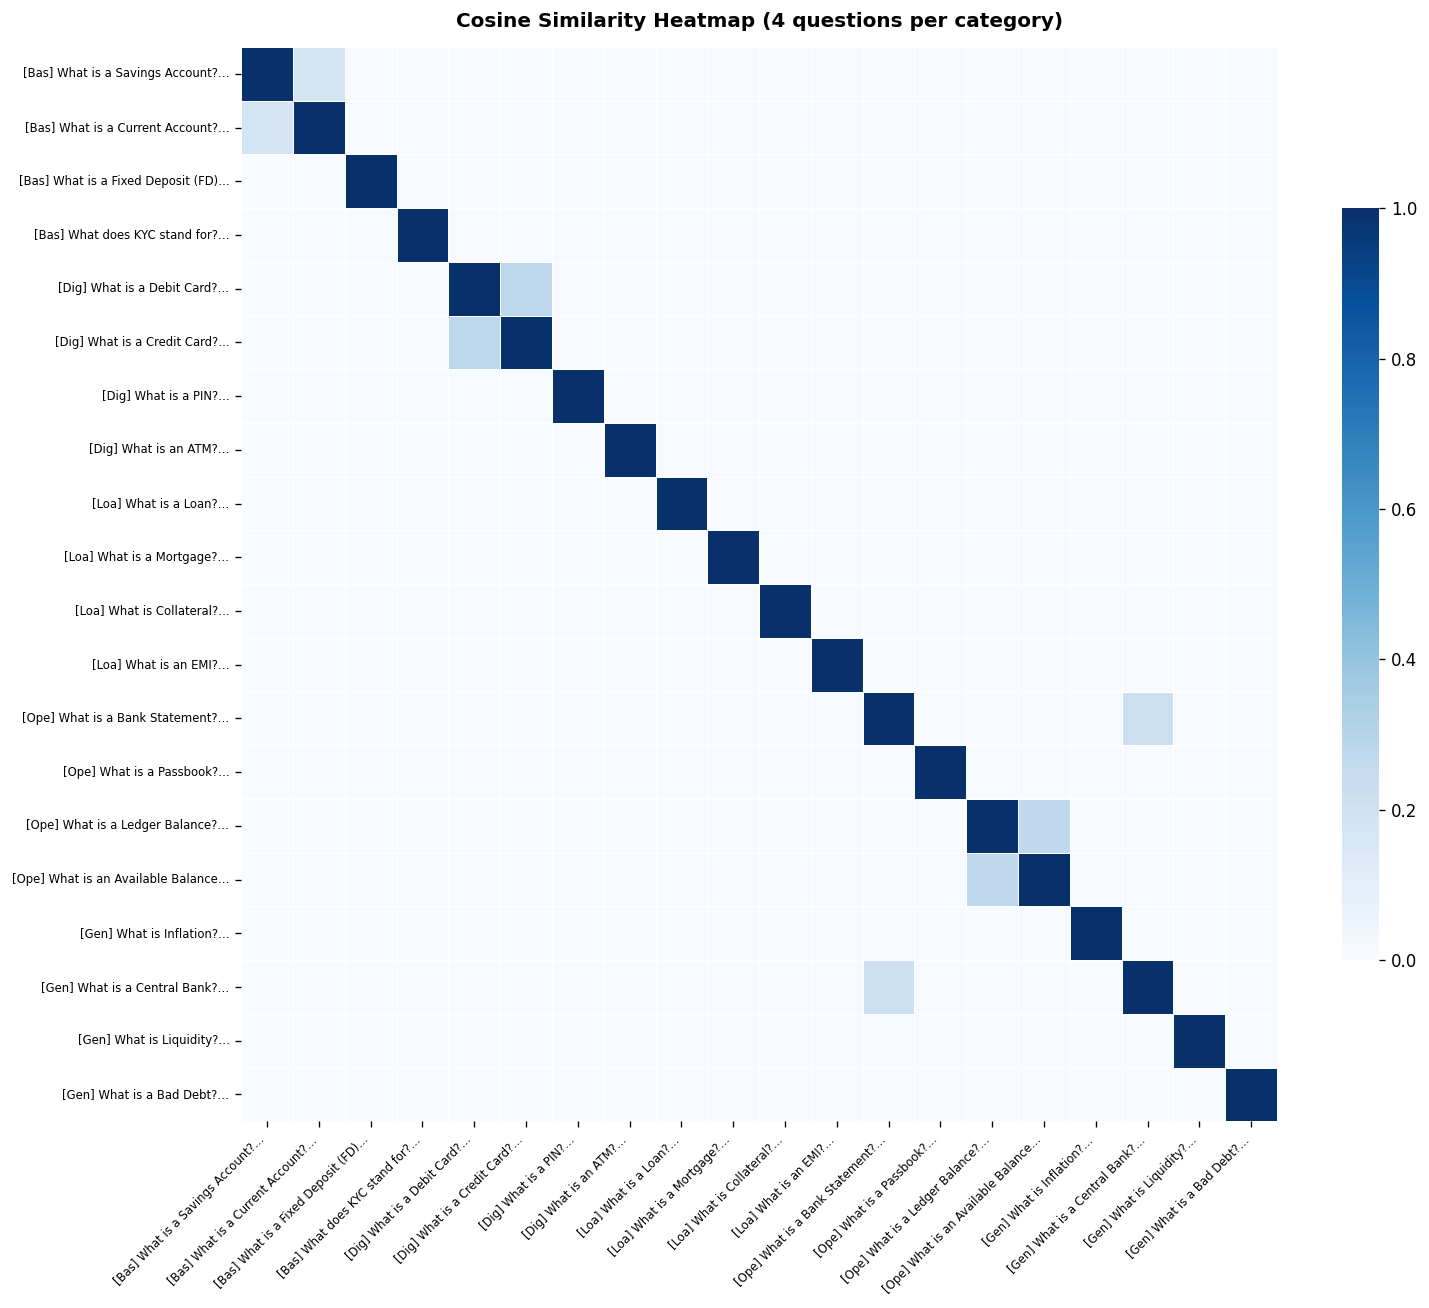

In [17]:
# ── Cosine similarity heatmap (sample of 20 questions) ─────────────────────
sample_idx = df.groupby('Category').head(4).index
sample_matrix = tfidf_matrix[sample_idx]
sample_labels = [
    f'[{row.Category[:3]}] {row.Question[:28]}…'
    for _, row in df.loc[sample_idx].iterrows()
]

sim_matrix = cosine_similarity(sample_matrix)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    sim_matrix,
    xticklabels=sample_labels, yticklabels=sample_labels,
    cmap='Blues', annot=False, linewidths=0.3,
    ax=ax, cbar_kws={'shrink': 0.7}
)
ax.set_title('Cosine Similarity Heatmap (4 questions per category)', fontsize=12, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

## 5 · Intent (Category) Classification
We treat each category as an intent label and train three classifiers. All use TF-IDF features from the question text.

In [18]:
X = df['clean_question']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train size : {len(X_train)}')
print(f'Test  size : {len(X_test)}')

Train size : 80
Test  size : 20


In [19]:
# ── Define pipelines ─────────────────────────────────────────────────────────
def make_pipeline(clf):
    return Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=2000,
                                  sublinear_tf=True, stop_words='english')),
        ('clf',  clf)
    ])

models = {
    'Logistic Regression': make_pipeline(LogisticRegression(max_iter=1000, C=1.0)),
    'Naive Bayes':         make_pipeline(MultinomialNB(alpha=0.1)),
    'Linear SVM':          make_pipeline(LinearSVC(max_iter=2000, C=1.0))
}

# ── Cross-validation accuracy (5-fold) ──────────────────────────────────────
print('5-Fold CV Accuracy')
print('-' * 40)
cv_scores = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    cv_scores[name] = scores
    print(f'{name:<25}  {scores.mean():.3f} ± {scores.std():.3f}')


5-Fold CV Accuracy
----------------------------------------
Logistic Regression        0.440 ± 0.086
Naive Bayes                0.390 ± 0.058
Linear SVM                 0.430 ± 0.068


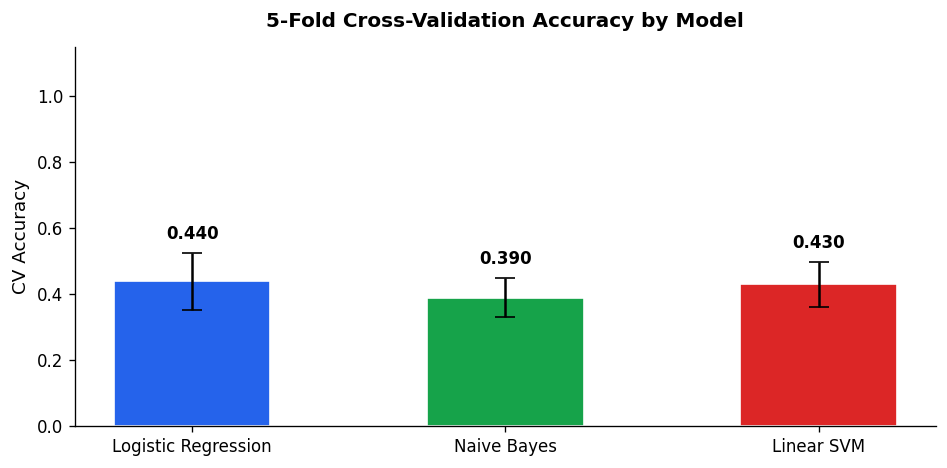

In [20]:
# ── Cross-validation bar chart ────────────────────────────────────────────
names = list(cv_scores.keys())
means = [cv_scores[n].mean() for n in names]
stds  = [cv_scores[n].std()  for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=PALETTE[:3], edgecolor='white', width=0.5)
ax.bar_label(bars, labels=[f'{m:.3f}' for m in means],
             padding=6, fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('CV Accuracy', fontsize=11)
ax.set_title('5-Fold Cross-Validation Accuracy by Model', fontsize=12, fontweight='bold', pad=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [21]:
# ── Train best model and evaluate on held-out test set ──────────────────────
best_name = max(cv_scores, key=lambda n: cv_scores[n].mean())
print(f'Best model: {best_name}')

best_pipe = models[best_name]
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

print('\nClassification Report (test set):')
print(classification_report(y_test, y_pred))

Best model: Logistic Regression

Classification Report (test set):
                       precision    recall  f1-score   support

       Basic Accounts       1.00      0.25      0.40         4
      Digital Banking       0.00      0.00      0.00         4
      General Finance       0.29      1.00      0.44         4
     Loans & Interest       0.75      0.75      0.75         4
Operations & Security       1.00      0.25      0.40         4

             accuracy                           0.45        20
            macro avg       0.61      0.45      0.40        20
         weighted avg       0.61      0.45      0.40        20



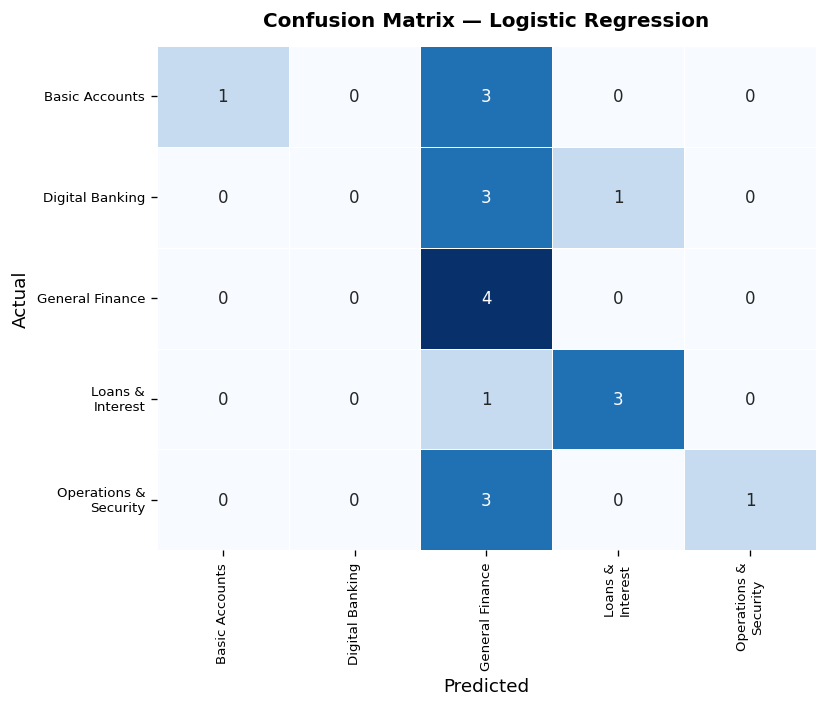

In [22]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
labels = sorted(y.unique())
short_labels = [l.replace(' & ', ' &\n') for l in labels]

cm_arr = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_arr,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=short_labels, yticklabels=short_labels,
    linewidths=0.5, ax=ax, cbar=False
)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=12, fontweight='bold', pad=12)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

## 6 · Interactive Chatbot Demo
Combines retrieval (Cosine Similarity) with intent prediction (best classifier) in a single response

In [23]:
def chatbot(query: str, top_k: int = 1, threshold: float = 0.05) -> None:
    """Print a formatted chatbot response for a given user query."""
    print('─' * 60)
    print(f'👤  You : {query}')
    print('─' * 60)

    # Predict intent
    intent = best_pipe.predict([preprocess(query)])[0]

    # Retrieve best match
    results = get_answer(query, top_k=top_k, threshold=threshold)

    if results.empty:
        print('🤖  Bot : Sorry, I couldn\'t find a relevant answer. Please contact support.')
    else:
        row = results.iloc[0]
        print(f'🎯  Intent detected : {intent}')
        print(f'📊  Similarity score: {row.Score}')
        print(f'\n🤖  Bot : {row.Answer}')
    print()
    
    
    # ── Demo queries ─────────────────────────────────────────────────────────────
demo_queries = [
    "How do I transfer money using UPI?",
    "What documents do I need for a personal loan?",
    "How can I protect my account from fraud?",
    "What is a mutual fund and how does it work?",
    "Can I open a savings account for my child?",
]

for q in demo_queries:
    chatbot(q)

────────────────────────────────────────────────────────────
👤  You : How do I transfer money using UPI?
────────────────────────────────────────────────────────────
🎯  Intent detected : Digital Banking
📊  Similarity score: 1.0

🤖  Bot : Unified Payments Interface; a real-time payment system that allows instant money transfer using a mobile phone.

────────────────────────────────────────────────────────────
👤  You : What documents do I need for a personal loan?
────────────────────────────────────────────────────────────
🎯  Intent detected : Loans & Interest
📊  Similarity score: 1.0

🤖  Bot : An unsecured loan used for various personal expenses like travel or weddings.

────────────────────────────────────────────────────────────
👤  You : How can I protect my account from fraud?
────────────────────────────────────────────────────────────
🎯  Intent detected : Basic Accounts
📊  Similarity score: 0.3933

🤖  Bot : Unauthorized access to a person's bank account through the internet to ste